In [14]:
import copy
import json
import pickle
import sys
from collections import deque
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [15]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split settings
VAL_FRAC = 0.2
SPLIT_SEED = 69

# Feature-subset experiment settings. No all-marker variant in this notebook.
FEATURE_VARIANTS = {
    "LGR5_only": ["LGR5"],
    "AldoB_only": ["AldoB"],
    "Lysozyme_Serotonin_Chroma": ["Lysozyme", "Serotonin", "Chroma"],
    "LGR5_Lysozyme_Serotonin_Chroma": ["LGR5", "Lysozyme", "Serotonin", "Chroma"],
}
FEATURE_VARIANT_LABELS = {
    "LGR5_only": "LGR5 only",
    "AldoB_only": "AldoB only",
    "Lysozyme_Serotonin_Chroma": "Lysozyme + Serotonin + Chroma",
    "LGR5_Lysozyme_Serotonin_Chroma": "LGR5 + Lysozyme + Serotonin + Chroma",
}

# FEATURE_VARIANTS = {
#     "Lyzo_only": ["Lysozyme"],
#     "Sero_only": ["Serotonin"],
#     "LGR5_Lyzo": ["LGR5", "Lysozyme"],
#     "LGR5_Sero": ["LGR5", "Serotonin"],
# }
# FEATURE_VARIANT_LABELS = {
#     "Lyzo_only": "Lyzo only",
#     "Sero_only": "Sero only",
#     "LGR5_Lyzo": "LGR5 + Lysozyme",
#     "LGR5_Sero": "LGR5 + Serotonin",
# }


DEPTH = 4
USE_SIGNED_CLUSTER_DISTANCE = True
MAX_DISTANCE_HOPS = 8  # None = plot all observed finite positive graph-hop distances
MIN_DISTANCE_HOPS = -MAX_DISTANCE_HOPS if MAX_DISTANCE_HOPS is not None else None
SHOW_DISTANCE_SAMPLE_COUNTS = False
MIN_DISTANCE_BIN_COUNT = 50
TRAIN_DEPTH0_BASELINE = True
BASELINE_DEPTH = 0
TRAIN_STRUCTURE_ONE_BASELINE = True
TRAIN_STRUCTURE_ZERO_BASELINE = True
STRUCTURE_ONE_CONSTANT_VALUE = 1.0
STRUCTURE_ZERO_CONSTANT_VALUE = 0.0

# Model settings
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Experiment output settings
EXPERIMENT_GROUP = "marker_subset_distance_comparison"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"


# Marker Subset Distance Comparison

Train one GIN model at a fixed depth for each reduced marker subset, then evaluate validation MSE as a function of graph-hop distance to the nearest retained marker-positive cell. Distance 0 corresponds to nodes that are themselves positive for at least one retained marker.

In [16]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def ensure_figure_dir():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURES_DIR


def save_mpl_figure(fig, name, *, close=False):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.pdf"
    fig.savefig(path, bbox_inches="tight", transparent=True)
    print(f"Saved figure -> {path}")
    if close:
        plt.close(fig)
    return path


## Load Data

In [17]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)


Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


## Filter And Preprocess

In [18]:
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.metadata import fill_missing_metadata_for_group
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

# graphs = graphs + g_spherical

print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_sphericity(max_sphericity=0.92): kept 819 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                244    342    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         290    411    0.706
20251201         day4p5              196    277    0.708
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 37     98    0.378
20250929         day4p5                9     15    0.600
20250929         day4p5-more          27    121    0.223
20251201         day4p5               20     81    0.247
filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 712 / 819 graphs

dataset          timepoint          kept  total

In [19]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


## Shared Split And Feature Variants

In [20]:
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)


Split -> train: 570 | val: 142
global_dim = 4
target_transform = asinh_standardize


In [21]:
from src.data.preprocessing import remove_marker_features


def _resolve_marker_name(name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if name in marker_names_in:
        return marker_names_in.index(name)

    lower_lookup = {str(m).lower(): i for i, m in enumerate(marker_names_in)}
    key = str(name).lower()
    if key not in lower_lookup:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names_in}")
    return lower_lookup[key]


def build_feature_variant(graphs_in, keep_markers, marker_names_in):
    marker_names_in = list(marker_names_in)
    keep_indices = {_resolve_marker_name(name, marker_names_in) for name in keep_markers}
    remove_names = [name for i, name in enumerate(marker_names_in) if i not in keep_indices]
    graphs_out, marker_names_out = remove_marker_features(
        graphs_in,
        remove_names,
        marker_names=marker_names_in,
        inplace=False,
        return_marker_names=True,
    )
    return graphs_out, marker_names_out


def build_structure_constant_graphs(graphs_in, *, constant_value):
    graphs_out = [copy.deepcopy(g) for g in graphs_in]
    for g in graphs_out:
        n_nodes = int(g.x.shape[0])
        g.x = torch.full(
            (n_nodes, 1),
            float(constant_value),
            dtype=g.x.dtype,
            device=g.x.device,
        )
    return graphs_out, [f"constant_node_feature_{constant_value:g}"]


feature_data = {}
for variant_name, keep_markers in FEATURE_VARIANTS.items():
    train_variant, marker_names_variant = build_feature_variant(g_train, keep_markers, marker_names)
    val_variant, marker_names_val_variant = build_feature_variant(g_val, keep_markers, marker_names)

    if marker_names_variant != marker_names_val_variant:
        raise RuntimeError(f"Train/val marker mismatch for {variant_name}")

    feature_data[variant_name] = {
        "g_train": train_variant,
        "g_val": val_variant,
        "marker_names": marker_names_variant,
        "keep_markers": list(keep_markers),
    }
    print(f"{variant_name}: kept markers = {marker_names_variant}")

structure_baseline_specs = []
if TRAIN_STRUCTURE_ONE_BASELINE:
    structure_baseline_specs.append({
        "name": "structure_one",
        "label": f"structure-one, depth {DEPTH}",
        "constant_value": STRUCTURE_ONE_CONSTANT_VALUE,
        "color": "#8a5a00",
        "style": ":^",
    })
if TRAIN_STRUCTURE_ZERO_BASELINE:
    structure_baseline_specs.append({
        "name": "structure_zero",
        "label": f"structure-zero, depth {DEPTH}",
        "constant_value": STRUCTURE_ZERO_CONSTANT_VALUE,
        "color": "#2ca02c",
        "style": ":v",
    })

structure_feature_data = {}
for spec in structure_baseline_specs:
    structure_train, structure_marker_names = build_structure_constant_graphs(
        g_train,
        constant_value=spec["constant_value"],
    )
    structure_val, structure_marker_names_val = build_structure_constant_graphs(
        g_val,
        constant_value=spec["constant_value"],
    )
    if structure_marker_names != structure_marker_names_val:
        raise RuntimeError(f"Train/val feature names do not match for {spec['name']}.")
    structure_feature_data[spec["name"]] = {
        "g_train": structure_train,
        "g_val": structure_val,
        "marker_names": structure_marker_names,
        "label": spec["label"],
        "constant_value": spec["constant_value"],
        "color": spec["color"],
        "style": spec["style"],
    }
    print(f"{spec['name']}: node features = {structure_marker_names}")


LGR5_only: kept markers = ['LGR5']
AldoB_only: kept markers = ['AldoB']
Lysozyme_Serotonin_Chroma: kept markers = ['Chroma', 'Lysozyme', 'Serotonin']
LGR5_Lysozyme_Serotonin_Chroma: kept markers = ['Chroma', 'LGR5', 'Lysozyme', 'Serotonin']
structure_one: node features = ['constant_node_feature_1']
structure_zero: node features = ['constant_node_feature_0']


## Train Models

In [22]:
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


In [23]:
trained_models = {}
baseline_models = {}
structure_baseline_models = {}
training_logs = {}
baseline_training_logs = {}
structure_baseline_training_logs = {}

for variant_name, pack in feature_data.items():
    print()
    print("=" * 80)
    print(f"Training GINCurvature | variant={variant_name} | depth={DEPTH}")

    model = GINCurvature(
        n_markers=int(pack["g_train"][0].x.size(1)),
        global_dim=infer_global_dim(pack["g_train"]),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(DEPTH),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )

    model, metrics, history = train(model, pack["g_train"], pack["g_val"], cfg)
    trained_models[variant_name] = model
    training_logs[variant_name] = {
        "variant": variant_name,
        "depth": int(DEPTH),
        "metrics": metrics,
        "history": history,
    }

    if TRAIN_DEPTH0_BASELINE:
        print(f"Training depth-{BASELINE_DEPTH} baseline | variant={variant_name}")
        baseline_model = GINCurvature(
            n_markers=int(pack["g_train"][0].x.size(1)),
            global_dim=infer_global_dim(pack["g_train"]),
            hidden_dim=HIDDEN_DIM,
            num_layers=int(BASELINE_DEPTH),
            dropout=DROPOUT,
            residual=RESIDUAL,
            norm=NORM,
        )
        baseline_model, baseline_metrics, baseline_history = train(
            baseline_model,
            pack["g_train"],
            pack["g_val"],
            cfg,
        )
        baseline_models[variant_name] = baseline_model
        baseline_training_logs[variant_name] = {
            "variant": variant_name,
            "depth": int(BASELINE_DEPTH),
            "metrics": baseline_metrics,
            "history": baseline_history,
        }

print("Finished training", len(trained_models), "models.")
if TRAIN_DEPTH0_BASELINE:
    print("Finished training", len(baseline_models), "depth-0 baseline models.")

for baseline_name, pack in structure_feature_data.items():
    print()
    print("=" * 80)
    print(f"Training {pack['label']}")
    structure_model = GINCurvature(
        n_markers=int(pack["g_train"][0].x.size(1)),
        global_dim=infer_global_dim(pack["g_train"]),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(DEPTH),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )
    structure_model, structure_metrics, structure_history = train(
        structure_model,
        pack["g_train"],
        pack["g_val"],
        cfg,
    )
    structure_baseline_models[baseline_name] = structure_model
    structure_baseline_training_logs[baseline_name] = {
        "variant": baseline_name,
        "label": pack["label"],
        "constant_value": pack["constant_value"],
        "depth": int(DEPTH),
        "metrics": structure_metrics,
        "history": structure_history,
    }
print("Finished training", len(structure_baseline_models), "structure-only baseline models.")



Training GINCurvature | variant=LGR5_only | depth=4
epoch 001 | train loss 1.4417 mae 0.8068 | val loss 0.5106 mae 0.7383
epoch 002 | train loss 0.5777 mae 0.7737 | val loss 0.4731 mae 0.7296
epoch 003 | train loss 0.5409 mae 0.7565 | val loss 0.4601 mae 0.7208
epoch 004 | train loss 0.5217 mae 0.7459 | val loss 0.4653 mae 0.7211
epoch 005 | train loss 0.5036 mae 0.7363 | val loss 0.4911 mae 0.7356
epoch 006 | train loss 0.4960 mae 0.7292 | val loss 0.4307 mae 0.6995
epoch 007 | train loss 0.4862 mae 0.7262 | val loss 0.4291 mae 0.6979
epoch 008 | train loss 0.4814 mae 0.7242 | val loss 0.4112 mae 0.6880
epoch 009 | train loss 0.4731 mae 0.7184 | val loss 0.4123 mae 0.6926
epoch 010 | train loss 0.4724 mae 0.7228 | val loss 0.4260 mae 0.6926
epoch 011 | train loss 0.4688 mae 0.7173 | val loss 0.4305 mae 0.7059
epoch 012 | train loss 0.4655 mae 0.7177 | val loss 0.4217 mae 0.6988
epoch 013 | train loss 0.4607 mae 0.7163 | val loss 0.4440 mae 0.7180
epoch 014 | train loss 0.4599 mae 0.7

## MSE By Distance To Kept Markers

In [24]:
from src.inference.predict import predict_targets


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def _build_undirected_adjacency(edge_index, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    ei = edge_index.detach().cpu().numpy() if hasattr(edge_index, "detach") else np.asarray(edge_index)
    for u, v in zip(ei[0], ei[1]):
        u = int(u)
        v = int(v)
        if u == v:
            continue
        adjacency[u].append(v)
        adjacency[v].append(u)
    return [sorted(set(neigh)) for neigh in adjacency]


def graph_distance_to_sources(adjacency, source_nodes):
    distances = np.full(len(adjacency), np.nan, dtype=float)
    source_nodes = [int(node) for node in source_nodes]
    if len(source_nodes) == 0:
        return distances

    queue = deque()
    for source in source_nodes:
        distances[source] = 0.0
        queue.append(source)

    while queue:
        node = queue.popleft()
        next_distance = distances[node] + 1.0
        for nbr in adjacency[node]:
            if np.isfinite(distances[nbr]):
                continue
            distances[nbr] = next_distance
            queue.append(nbr)

    return distances


def _restrict_adjacency_to_mask(adjacency, mask):
    mask = np.asarray(mask, dtype=bool)
    return [
        [nbr for nbr in neighbors if mask[nbr]] if mask[i] else []
        for i, neighbors in enumerate(adjacency)
    ]


def graph_signed_distance_to_marker_cluster(graph, source_mask, *, signed_cluster_distance=True):
    n_nodes = int(graph.x.shape[0])
    source_mask = np.asarray(source_mask, dtype=bool).reshape(-1)
    if source_mask.shape[0] != n_nodes:
        raise ValueError(f"source_mask length {source_mask.shape[0]} does not match graph nodes {n_nodes}.")

    source_nodes = np.where(source_mask)[0]
    if source_nodes.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)

    adjacency = _build_undirected_adjacency(graph.edge_index, n_nodes)
    if not signed_cluster_distance:
        return graph_distance_to_sources(adjacency, source_nodes)

    boundary_nodes = []
    for node in source_nodes:
        neighbors = adjacency[int(node)]
        is_boundary = len(neighbors) == 0 or any(not source_mask[nbr] for nbr in neighbors)
        if is_boundary:
            boundary_nodes.append(int(node))

    # If every cell is marker-positive in a connected component, there is no external
    # boundary. Treat those cells as distance 0 rather than inventing an interior depth.
    if len(boundary_nodes) == 0:
        distances = np.full(n_nodes, np.nan, dtype=float)
        distances[source_nodes] = 0.0
        return distances

    distances_from_boundary = graph_distance_to_sources(adjacency, boundary_nodes)
    marker_only_adjacency = _restrict_adjacency_to_mask(adjacency, source_mask)
    interior_distances = graph_distance_to_sources(marker_only_adjacency, boundary_nodes)

    signed_distances = distances_from_boundary.copy()
    interior_mask = source_mask & np.isfinite(interior_distances)
    signed_distances[interior_mask] = -interior_distances[interior_mask]
    signed_distances[boundary_nodes] = 0.0
    return signed_distances


def distance_to_kept_markers_for_graphs(
    graphs_in,
    keep_markers,
    marker_names_in,
    *,
    signed_cluster_distance=True,
):
    keep_indices = [_resolve_marker_name(name, marker_names_in) for name in keep_markers]
    all_distances = []
    for g in graphs_in:
        x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
        source_mask = np.any(x[:, keep_indices] > 0.5, axis=1)
        all_distances.append(
            graph_signed_distance_to_marker_cluster(
                g,
                source_mask,
                signed_cluster_distance=signed_cluster_distance,
            )
        )
    return np.concatenate(all_distances, axis=0)


def summarize_mse_by_distance(y_true, y_pred, distances, *, min_distance=None, max_distance=None):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    distances = np.asarray(distances, dtype=float).reshape(-1)
    if not (len(y_true) == len(y_pred) == len(distances)):
        raise ValueError("y_true, y_pred, and distances must have matching lengths.")

    finite = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(distances)
    if min_distance is not None:
        finite = finite & (distances >= min_distance)
    if max_distance is not None:
        finite = finite & (distances <= max_distance)

    distance_int = np.full(len(distances), -1, dtype=int)
    distance_int[finite] = distances[finite].astype(int)

    rows = []
    for distance in sorted(np.unique(distance_int[finite])):
        mask = finite & (distance_int == int(distance))
        sq_err = (y_pred[mask] - y_true[mask]) ** 2
        rows.append({
            "distance": int(distance),
            "mse": float(np.mean(sq_err)),
            "sem": float(np.std(sq_err, ddof=1) / np.sqrt(len(sq_err))) if len(sq_err) > 1 else 0.0,
            "n_nodes": int(len(sq_err)),
        })
    return pd.DataFrame(rows)


predictions_by_variant = {}
distance_mse_tables = {}
positive_distance_mse_tables = {}
baseline_distance_mse_tables = {}
baseline_positive_distance_mse_tables = {}
structure_distance_mse_tables = {name: {} for name in structure_baseline_models}
structure_positive_distance_mse_tables = {name: {} for name in structure_baseline_models}
structure_predictions = {}
truth_reference = None

for baseline_name, model in structure_baseline_models.items():
    pack = structure_feature_data[baseline_name]
    structure_y_true, structure_y_pred, structure_log_var, _ = predict_targets(
        pack["g_val"],
        model,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )
    structure_predictions[baseline_name] = {
        "y_true": select_target_column(structure_y_true, TARGET_INDEX_FOR_PLOTS),
        "y_pred": select_target_column(structure_y_pred, TARGET_INDEX_FOR_PLOTS),
        "log_var": select_target_column(structure_log_var, TARGET_INDEX_FOR_PLOTS),
    }

for variant_name, pack in feature_data.items():
    model = trained_models[variant_name]
    y_true, y_pred, log_var, X_pred = predict_targets(
        pack["g_val"],
        model,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )

    y_true_plot = select_target_column(y_true, TARGET_INDEX_FOR_PLOTS)
    y_pred_plot = select_target_column(y_pred, TARGET_INDEX_FOR_PLOTS)
    log_var_plot = select_target_column(log_var, TARGET_INDEX_FOR_PLOTS)

    if truth_reference is None:
        truth_reference = y_true_plot.copy()
    elif not np.allclose(truth_reference, y_true_plot, equal_nan=True):
        raise RuntimeError("Validation truth differs between feature variants; split/base graphs are not aligned.")

    distances = distance_to_kept_markers_for_graphs(
        g_val,
        pack["keep_markers"],
        marker_names,
        signed_cluster_distance=USE_SIGNED_CLUSTER_DISTANCE,
    )

    predictions_by_variant[variant_name] = {
        "y_true": y_true_plot,
        "y_pred": y_pred_plot,
        "log_var": log_var_plot,
        "distance_to_kept_marker": distances,
    }

    table = summarize_mse_by_distance(
        y_true_plot,
        y_pred_plot,
        distances,
        min_distance=MIN_DISTANCE_HOPS,
        max_distance=MAX_DISTANCE_HOPS,
    )
    table["variant"] = variant_name
    table["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
    distance_mse_tables[variant_name] = table

    positive_distances = np.maximum(distances, 0)
    positive_table = summarize_mse_by_distance(
        y_true_plot,
        y_pred_plot,
        positive_distances,
        min_distance=0,
        max_distance=MAX_DISTANCE_HOPS,
    )
    positive_table["variant"] = variant_name
    positive_table["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
    positive_distance_mse_tables[variant_name] = positive_table

    if TRAIN_DEPTH0_BASELINE:
        baseline_model = baseline_models[variant_name]
        y_true_base, y_pred_base, log_var_base, _ = predict_targets(
            pack["g_val"],
            baseline_model,
            device=device,
            batch_size=PREDICT_BATCH_SIZE,
            target_transform=target_transform,
            return_log_var=True,
        )
        y_true_base_plot = select_target_column(y_true_base, TARGET_INDEX_FOR_PLOTS)
        y_pred_base_plot = select_target_column(y_pred_base, TARGET_INDEX_FOR_PLOTS)
        log_var_base_plot = select_target_column(log_var_base, TARGET_INDEX_FOR_PLOTS)
        if not np.allclose(y_true_plot, y_true_base_plot, equal_nan=True):
            raise RuntimeError(f"Baseline validation truth differs for {variant_name}.")

        baseline_table = summarize_mse_by_distance(
            y_true_base_plot,
            y_pred_base_plot,
            distances,
            min_distance=MIN_DISTANCE_HOPS,
            max_distance=MAX_DISTANCE_HOPS,
        )
        baseline_table["variant"] = variant_name
        baseline_table["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
        baseline_distance_mse_tables[variant_name] = baseline_table

        baseline_positive_table = summarize_mse_by_distance(
            y_true_base_plot,
            y_pred_base_plot,
            positive_distances,
            min_distance=0,
            max_distance=MAX_DISTANCE_HOPS,
        )
        baseline_positive_table["variant"] = variant_name
        baseline_positive_table["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
        baseline_positive_distance_mse_tables[variant_name] = baseline_positive_table

        predictions_by_variant[variant_name]["baseline_y_pred"] = y_pred_base_plot
        predictions_by_variant[variant_name]["baseline_log_var"] = log_var_base_plot

    for baseline_name, baseline_pred in structure_predictions.items():
        if not np.allclose(y_true_plot, baseline_pred["y_true"], equal_nan=True):
            raise RuntimeError(f"{baseline_name} validation truth differs for {variant_name}.")

        structure_table = summarize_mse_by_distance(
            baseline_pred["y_true"],
            baseline_pred["y_pred"],
            distances,
            min_distance=MIN_DISTANCE_HOPS,
            max_distance=MAX_DISTANCE_HOPS,
        )
        structure_table["variant"] = variant_name
        structure_table["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
        structure_distance_mse_tables[baseline_name][variant_name] = structure_table

        structure_positive_table = summarize_mse_by_distance(
            baseline_pred["y_true"],
            baseline_pred["y_pred"],
            positive_distances,
            min_distance=0,
            max_distance=MAX_DISTANCE_HOPS,
        )
        structure_positive_table["variant"] = variant_name
        structure_positive_table["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
        structure_positive_distance_mse_tables[baseline_name][variant_name] = structure_positive_table

        predictions_by_variant[variant_name][f"{baseline_name}_y_pred"] = baseline_pred["y_pred"]
        predictions_by_variant[variant_name][f"{baseline_name}_log_var"] = baseline_pred["log_var"]

    print(
        f"{variant_name}: computed MSE for {len(table)} signed distance bins "
        f"and {len(positive_table)} positive distance bins."
    )


LGR5_only: computed MSE for 17 signed distance bins and 9 positive distance bins.
AldoB_only: computed MSE for 17 signed distance bins and 9 positive distance bins.
Lysozyme_Serotonin_Chroma: computed MSE for 10 signed distance bins and 9 positive distance bins.
LGR5_Lysozyme_Serotonin_Chroma: computed MSE for 17 signed distance bins and 9 positive distance bins.


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_distance_comparison/run_20260512_132232/figures/mse_vs_distance_to_kept_markers_by_variant.pdf


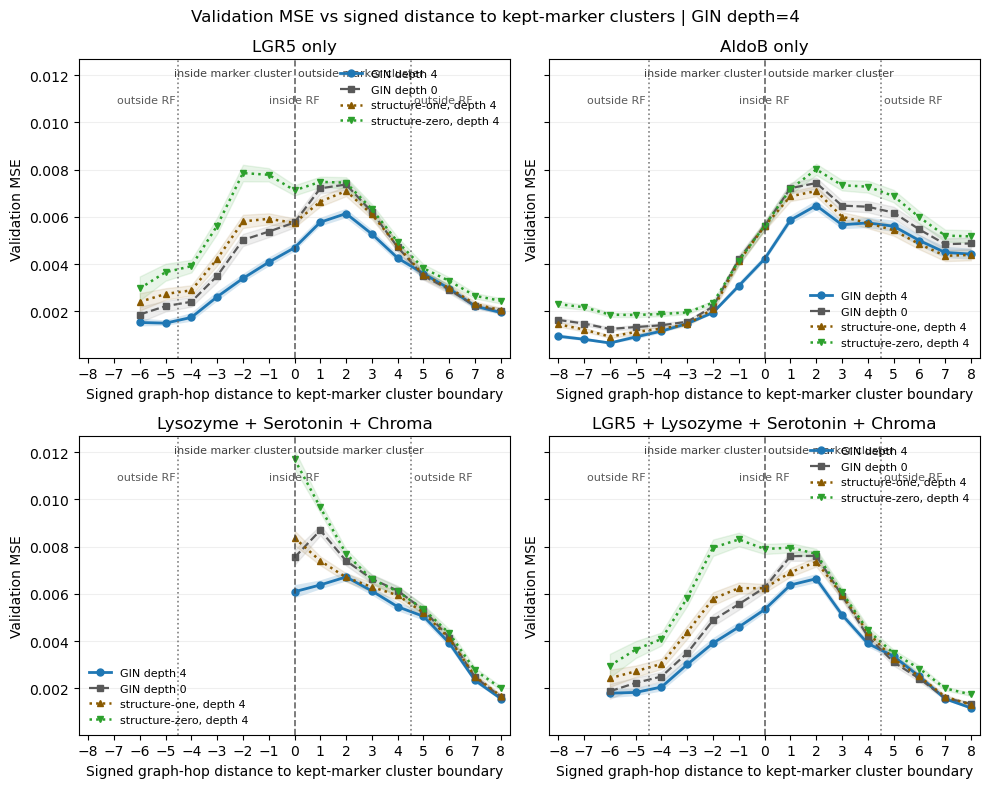

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_distance_comparison/run_20260512_132232/figures/mse_vs_positive_distance_to_kept_markers_by_variant.pdf


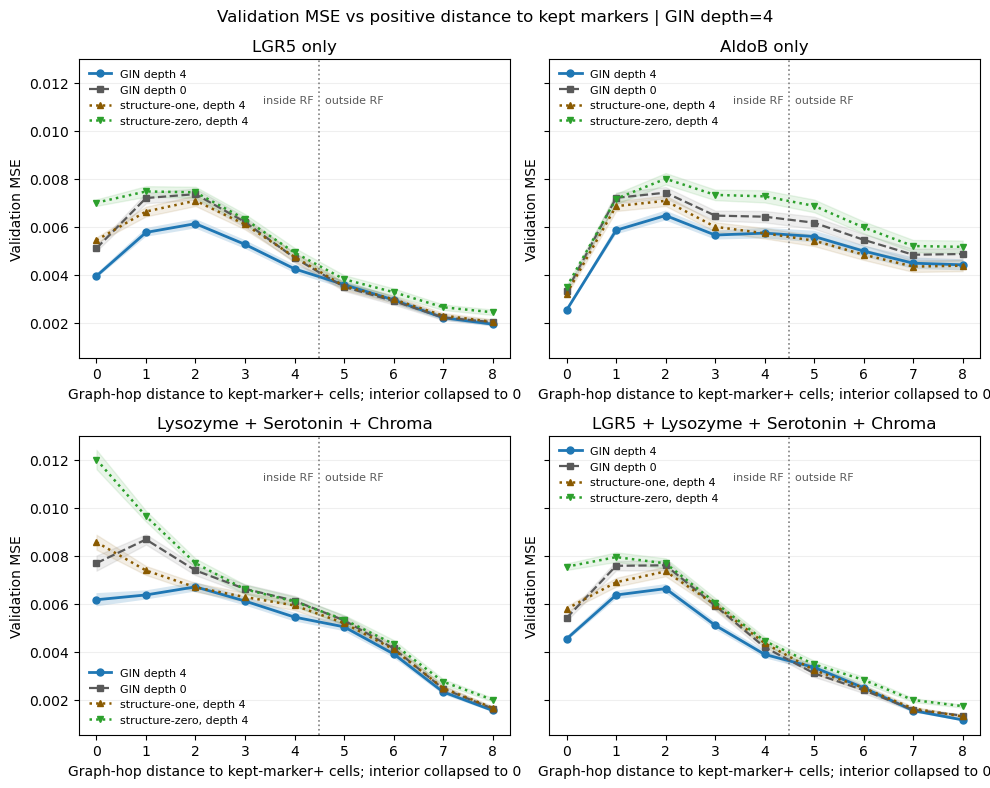

In [25]:
variant_order = list(FEATURE_VARIANTS.keys())


def _distance_axis_bounds(tables, *, signed=False):
    all_distances = np.concatenate([
        tables[name]["distance"].to_numpy(dtype=int)
        for name in variant_order
        if len(tables[name]) > 0
    ]) if variant_order else np.array([0])
    if len(all_distances) == 0:
        all_distances = np.array([0])

    if MAX_DISTANCE_HOPS is not None:
        x_max = int(MAX_DISTANCE_HOPS)
        x_min = -x_max if signed else 0
    else:
        x_min = int(min(0, np.nanmin(all_distances))) if signed else 0
        x_max = int(max(0, np.nanmax(all_distances)))
    return x_min, x_max


def _draw_receptive_field_guides(ax, *, x_min, x_max, signed=False):
    rf = int(DEPTH)
    if rf < 0:
        return

    # Distance bins are centered on integers. The receptive-field transition is
    # between the last visible bin (±rf) and the first invisible bin (±(rf + 1)).
    pos_boundary = rf + 0.5
    neg_boundary = -rf - 0.5

    x_transform = ax.get_xaxis_transform()
    guide_kwargs = dict(color="0.45", linestyle=":", linewidth=1.2, alpha=0.9)
    text_kwargs = dict(transform=x_transform, va="top", fontsize=8, color="0.35")

    if signed:
        if x_min <= neg_boundary <= x_max:
            ax.axvline(neg_boundary, **guide_kwargs)
            ax.text(neg_boundary - 0.12, 0.88, "outside RF", ha="right", **text_kwargs)
        if x_min <= pos_boundary <= x_max:
            ax.axvline(pos_boundary, **guide_kwargs)
            ax.text(pos_boundary + 0.12, 0.88, "outside RF", ha="left", **text_kwargs)
        if x_min < 0 < x_max:
            ax.text(0, 0.88, "inside RF", ha="center", **text_kwargs)
    else:
        if x_min <= pos_boundary <= x_max:
            ax.axvline(pos_boundary, **guide_kwargs)
            ax.text(pos_boundary - 0.12, 0.88, "inside RF", ha="right", **text_kwargs)
            ax.text(pos_boundary + 0.12, 0.88, "outside RF", ha="left", **text_kwargs)


def _filter_distance_table_for_plot(table, *, count_col="n_nodes"):
    if table is None or len(table) == 0:
        return pd.DataFrame() if table is None else table.copy()
    if MIN_DISTANCE_BIN_COUNT is None or count_col not in table.columns:
        return table.copy()
    return table.loc[table[count_col] >= MIN_DISTANCE_BIN_COUNT].copy()


def plot_distance_mse_panels(
    tables,
    *,
    baseline_tables=None,
    structure_tables=None,
    x_min,
    x_max,
    xlabel,
    title,
    filename,
    show_signed_annotations=False,
):
    x_ticks = np.arange(x_min, x_max + 1, dtype=int)
    x_pad = 0.35
    n_variants = len(variant_order)
    n_cols = min(2, n_variants)
    n_rows = int(np.ceil(n_variants / n_cols)) if n_variants else 1

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.0 * n_cols, 4.0 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax_i, variant_name in enumerate(variant_order):
        ax = axes[ax_i]
        table = _filter_distance_table_for_plot(tables[variant_name]).sort_values("distance")
        label = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)

        ax.plot(
            table["distance"],
            table["mse"],
            "-o",
            linewidth=2,
            markersize=5,
            label=f"GIN depth {DEPTH}",
        )
        if "sem" in table.columns:
            ax.fill_between(
                table["distance"].to_numpy(),
                (table["mse"] - table["sem"]).to_numpy(),
                (table["mse"] + table["sem"]).to_numpy(),
                alpha=0.18,
            )

        if baseline_tables is not None and variant_name in baseline_tables:
            baseline_table = _filter_distance_table_for_plot(baseline_tables[variant_name]).sort_values("distance")
            ax.plot(
                baseline_table["distance"],
                baseline_table["mse"],
                "--s",
                color="0.35",
                linewidth=1.6,
                markersize=4,
                label=f"GIN depth {BASELINE_DEPTH}",
            )
            if "sem" in baseline_table.columns:
                ax.fill_between(
                    baseline_table["distance"].to_numpy(),
                    (baseline_table["mse"] - baseline_table["sem"]).to_numpy(),
                    (baseline_table["mse"] + baseline_table["sem"]).to_numpy(),
                    color="0.35",
                    alpha=0.10,
                )

        if structure_tables is not None:
            for structure_name, structure_family_tables in structure_tables.items():
                if variant_name not in structure_family_tables:
                    continue
                spec = structure_feature_data[structure_name]
                structure_table = _filter_distance_table_for_plot(
                    structure_family_tables[variant_name]
                ).sort_values("distance")
                ax.plot(
                    structure_table["distance"],
                    structure_table["mse"],
                    spec["style"],
                    color=spec["color"],
                    linewidth=1.8,
                    markersize=4,
                    label=spec["label"],
                )
                if "sem" in structure_table.columns:
                    ax.fill_between(
                        structure_table["distance"].to_numpy(),
                        (structure_table["mse"] - structure_table["sem"]).to_numpy(),
                        (structure_table["mse"] + structure_table["sem"]).to_numpy(),
                        color=spec["color"],
                        alpha=0.10,
                    )

        if SHOW_DISTANCE_SAMPLE_COUNTS:
            for _, row in table.iterrows():
                ax.annotate(
                    f"n={int(row['n_nodes'])}",
                    (row["distance"], row["mse"]),
                    textcoords="offset points",
                    xytext=(0, 6),
                    ha="center",
                    fontsize=8,
                )

        if show_signed_annotations:
            ax.axvline(0, color="0.25", linestyle="--", linewidth=1.2, alpha=0.8)
            x_transform = ax.get_xaxis_transform()
            ax.text(
                -0.12,
                0.97,
                "inside marker cluster",
                transform=x_transform,
                ha="right",
                va="top",
                fontsize=8,
                color="0.25",
            )
            ax.text(
                0.12,
                0.97,
                "outside marker cluster",
                transform=x_transform,
                ha="left",
                va="top",
                fontsize=8,
                color="0.25",
            )

        _draw_receptive_field_guides(ax, x_min=x_min, x_max=x_max, signed=show_signed_annotations)

        ax.set_title(label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Validation MSE")
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_xticks(x_ticks)
        ax.tick_params(axis="x", which="both", labelbottom=True)
        ax.grid(True, axis="y", alpha=0.2)
        ax.legend(frameon=False, fontsize=8)

    for ax in axes[n_variants:]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


signed_x_min, signed_x_max = _distance_axis_bounds(distance_mse_tables, signed=USE_SIGNED_CLUSTER_DISTANCE)
fig_signed, axes_signed = plot_distance_mse_panels(
    distance_mse_tables,
    baseline_tables=baseline_distance_mse_tables if TRAIN_DEPTH0_BASELINE else None,
    structure_tables=structure_distance_mse_tables if len(structure_distance_mse_tables) else None,
    x_min=signed_x_min,
    x_max=signed_x_max,
    xlabel=(
        "Signed graph-hop distance to kept-marker cluster boundary"
        if USE_SIGNED_CLUSTER_DISTANCE
        else "Graph-hop distance to nearest kept marker+ cell"
    ),
    title=(
        f"Validation MSE vs signed distance to kept-marker clusters | GIN depth={DEPTH}"
        if USE_SIGNED_CLUSTER_DISTANCE
        else f"Validation MSE vs distance to kept markers | GIN depth={DEPTH}"
    ),
    filename="mse_vs_distance_to_kept_markers_by_variant",
    show_signed_annotations=USE_SIGNED_CLUSTER_DISTANCE,
)

positive_x_min, positive_x_max = _distance_axis_bounds(positive_distance_mse_tables, signed=False)
fig_positive, axes_positive = plot_distance_mse_panels(
    positive_distance_mse_tables,
    baseline_tables=baseline_positive_distance_mse_tables if TRAIN_DEPTH0_BASELINE else None,
    structure_tables=structure_positive_distance_mse_tables if len(structure_positive_distance_mse_tables) else None,
    x_min=positive_x_min,
    x_max=positive_x_max,
    xlabel="Graph-hop distance to kept-marker+ cells; interior collapsed to 0",
    title=f"Validation MSE vs positive distance to kept markers | GIN depth={DEPTH}",
    filename="mse_vs_positive_distance_to_kept_markers_by_variant",
    show_signed_annotations=False,
)


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_distance_comparison/run_20260512_132232/figures/delta_mse_vs_signed_distance_combined_baselines.pdf


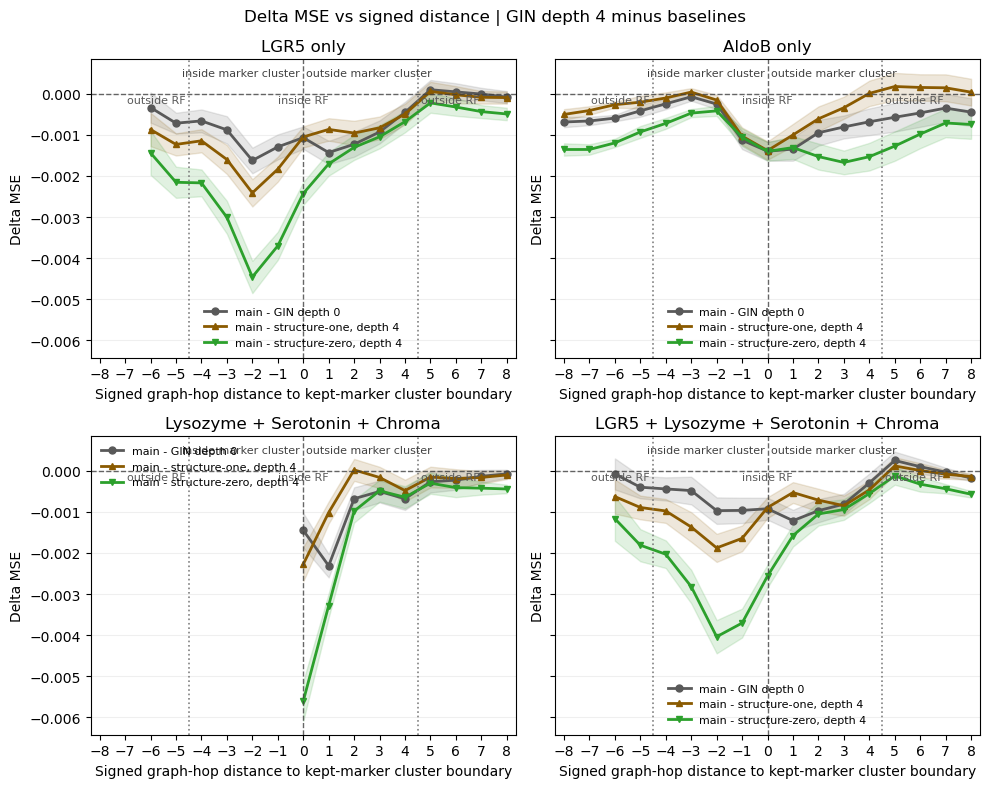

In [26]:
# Difference plots: main-model MSE minus baseline MSE

def make_mse_difference_tables(main_tables, reference_tables, *, reference_label):
    diff_tables = {}
    for variant_name in variant_order:
        if variant_name not in main_tables or variant_name not in reference_tables:
            continue

        main = _filter_distance_table_for_plot(main_tables[variant_name]).copy()
        reference = _filter_distance_table_for_plot(reference_tables[variant_name]).copy()
        merged = main.merge(
            reference,
            on="distance",
            suffixes=("_main", "_reference"),
            how="inner",
            validate="one_to_one",
        )
        if len(merged) == 0:
            diff_tables[variant_name] = pd.DataFrame(
                columns=["distance", "delta_mse", "sem", "n_nodes", "variant", "variant_label"]
            )
            continue

        missing_from_reference = sorted(set(main["distance"]) - set(reference["distance"]))
        missing_from_main = sorted(set(reference["distance"]) - set(main["distance"]))
        if missing_from_reference or missing_from_main:
            print(
                f"{variant_name} / {reference_label}: unmatched filtered distance bins; "
                f"main-only={missing_from_reference}, reference-only={missing_from_main}"
            )

        if not np.array_equal(merged["n_nodes_main"].to_numpy(), merged["n_nodes_reference"].to_numpy()):
            print(f"{variant_name} / {reference_label}: n_nodes differs between main and reference tables.")

        merged["delta_mse"] = merged["mse_main"] - merged["mse_reference"]
        merged["sem"] = np.sqrt(merged["sem_main"] ** 2 + merged["sem_reference"] ** 2)
        merged["n_nodes"] = merged[["n_nodes_main", "n_nodes_reference"]].min(axis=1).astype(int)
        merged["variant"] = variant_name
        merged["variant_label"] = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
        merged["reference_label"] = reference_label
        diff_tables[variant_name] = merged[
            ["distance", "delta_mse", "sem", "n_nodes", "variant", "variant_label", "reference_label"]
        ]
    return diff_tables


def plot_combined_mse_difference_panels(diff_specs, *, title, filename):
    x_min, x_max = _distance_axis_bounds(distance_mse_tables, signed=True)
    x_ticks = np.arange(x_min, x_max + 1, dtype=int)
    x_pad = 0.35
    n_variants = len(variant_order)
    n_cols = min(2, n_variants)
    n_rows = int(np.ceil(n_variants / n_cols)) if n_variants else 1

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.0 * n_cols, 4.0 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax_i, variant_name in enumerate(variant_order):
        ax = axes[ax_i]
        label = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)

        for spec in diff_specs:
            table = spec["tables"].get(variant_name, pd.DataFrame()).sort_values("distance")
            if len(table) == 0:
                continue

            ax.plot(
                table["distance"],
                table["delta_mse"],
                spec["style"],
                color=spec["color"],
                linewidth=spec.get("linewidth", 2),
                markersize=spec.get("markersize", 5),
                label=spec["label"],
            )
            if "sem" in table.columns:
                ax.fill_between(
                    table["distance"].to_numpy(),
                    (table["delta_mse"] - table["sem"]).to_numpy(),
                    (table["delta_mse"] + table["sem"]).to_numpy(),
                    color=spec["color"],
                    alpha=0.14,
                )

        ax.axhline(0, color="0.25", linestyle="--", linewidth=1.0, alpha=0.8)
        ax.axvline(0, color="0.25", linestyle="--", linewidth=1.0, alpha=0.8)
        x_transform = ax.get_xaxis_transform()
        ax.text(
            -0.12,
            0.97,
            "inside marker cluster",
            transform=x_transform,
            ha="right",
            va="top",
            fontsize=8,
            color="0.25",
        )
        ax.text(
            0.12,
            0.97,
            "outside marker cluster",
            transform=x_transform,
            ha="left",
            va="top",
            fontsize=8,
            color="0.25",
        )
        _draw_receptive_field_guides(ax, x_min=x_min, x_max=x_max, signed=True)

        ax.set_title(label)
        ax.set_xlabel("Signed graph-hop distance to kept-marker cluster boundary")
        ax.set_ylabel("Delta MSE")
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_xticks(x_ticks)
        ax.tick_params(axis="x", which="both", labelbottom=True)
        ax.grid(True, axis="y", alpha=0.2)
        ax.legend(frameon=False, fontsize=8)

    for ax in axes[n_variants:]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


diff_specs = []
if TRAIN_DEPTH0_BASELINE:
    depth0_diff_tables = make_mse_difference_tables(
        distance_mse_tables,
        baseline_distance_mse_tables,
        reference_label=f"GIN depth {BASELINE_DEPTH}",
    )
    diff_specs.append({
        "tables": depth0_diff_tables,
        "label": f"main - GIN depth {BASELINE_DEPTH}",
        "style": "-o",
        "color": "0.35",
        "linewidth": 2.0,
        "markersize": 5,
    })
else:
    print("Skipping depth-0 delta because TRAIN_DEPTH0_BASELINE is False.")

for baseline_name, baseline_tables in structure_distance_mse_tables.items():
    spec = structure_feature_data[baseline_name]
    structure_diff_tables = make_mse_difference_tables(
        distance_mse_tables,
        baseline_tables,
        reference_label=spec["label"],
    )
    diff_specs.append({
        "tables": structure_diff_tables,
        "label": f"main - {spec['label']}",
        "style": spec["style"].replace(":", "-"),
        "color": spec["color"],
        "linewidth": 2.0,
        "markersize": 5,
    })

if len(structure_distance_mse_tables) == 0:
    print("Skipping structure-only deltas because no structure baselines are enabled.")

if len(diff_specs) == 0:
    print("No delta-MSE baselines enabled.")
else:
    fig_delta_combined, axes_delta_combined = plot_combined_mse_difference_panels(
        diff_specs,
        title=f"Delta MSE vs signed distance | GIN depth {DEPTH} minus baselines",
        filename="delta_mse_vs_signed_distance_combined_baselines",
    )
